¿Qué grupo de clientes gasta más en iFood: los solteros o los casados? Usa
visualizaciones y estadísticas para justificar tu respuesta.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/desp/Desktop/IFOOD-EDA/src/ml_project1_data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Re create the global spendings variable

In [21]:
df["Total_Spending"] = df[["MntWines", "MntMeatProducts", "MntFishProducts","MntSweetProducts", "MntGoldProds"]].sum(axis=1)

Group by each marital status to know which of alone or married spend the most

In [22]:
df.groupby("Marital_Status")["Total_Spending"].mean()

Marital_Status
Absurd      1108.000000
Alone        252.666667
Divorced     583.202586
Married      565.067130
Single       579.647917
Together     583.037931
Widow        705.727273
YOLO         421.000000
Name: Total_Spending, dtype: float64

Graph showing spending by marital status

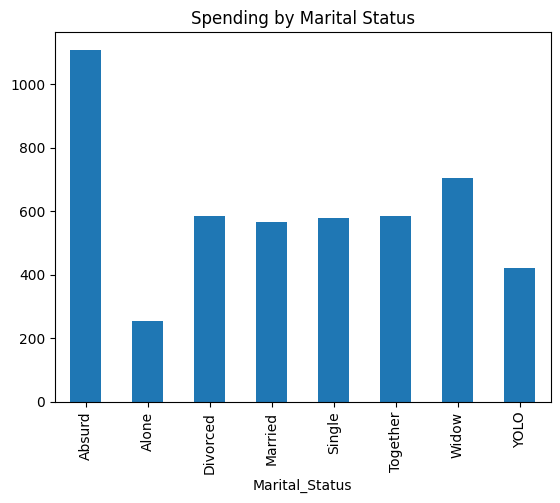

In [28]:
df.groupby("Marital_Status")["Total_Spending"].mean().plot(kind="bar")
plt.title("Spending by Marital Status")
plt.show()

Group each categories into two distincts categories (Solo,Couple)

In [23]:
def categorize_marital(status):
    if status in ["Single", "Alone", "Widow", "YOLO", "Absurd"]:
        return "Solo"
    elif status in ["Married", "Together", "Divorced"]:
        return "Couple"
    else:
        return None

In [24]:
df["Marital_Group"] = df["Marital_Status"].apply(categorize_marital)

Count the values by new category

In [25]:
df["Marital_Group"].value_counts()

Marital_Group
Couple    1676
Solo       564
Name: count, dtype: int64

Compare the means of the 2 new categories

In [26]:
df.groupby("Marital_Group")["Total_Spending"].mean()

Marital_Group
Couple    573.796539
Solo      596.432624
Name: Total_Spending, dtype: float64

Graph showing spending by marital status (new)

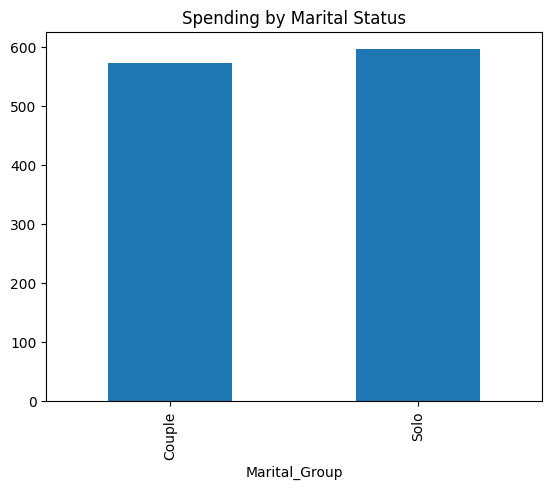

In [27]:
df.groupby("Marital_Group")["Total_Spending"].mean().plot(kind="bar")
plt.title("Spending by Marital Status")
plt.show()

Both categories have similar means, but we can see that solo people spend a bit much because people in couple cook more often.